Primer Parcial

Estudiante: Chelsea Melany Espinoza Cava

Carrera: Ing. de Sistemas

¿Qué es el Dataset NHANES?
Es una de las bases de datos de salud más importantes del mundo, recolectada por el CDC de EE. UU. Lo que la hace especial es que no es solo una encuesta, sino una combinación de dos fuentes:

Entrevistas: Datos demográficos, socioeconómicos y de dieta (lo que la gente dice).

Exámenes Físicos: Pruebas de laboratorio reales, sangre, orina y medidas corporales (lo que la gente realmente tiene).

In [29]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import KNNImputer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

In [30]:
# 1. CARGAR (Pandas lee archivos .XPT directamente)
# Asegúrate de que los archivos estén en tu carpeta de trabajo
df_demo = pd.read_sas('DEMO_L.XPT')
df_body = pd.read_sas('BMX_L.XPT')

# 2. UNIR (Merge por SEQN, que es el ID del participante)
df_nhanes = pd.merge(df_demo, df_body, on='SEQN', how='inner')

print(f"Dataset NHANES unido. Tamaño: {df_nhanes.shape}")

Dataset NHANES unido. Tamaño: (8860, 48)


In [31]:
# Verificar nulos
print("\n--- Conteo de Nulos por Columna ---")
nulos = df_nhanes.isnull().sum()
print(nulos[nulos > 0])

print(f"\nTotal general de nulos: {df_nhanes.isnull().sum().sum()}")


--- Conteo de Nulos por Columna ---
RIDAGEMN    8608
RIDEXAGM    6073
DMQMILIZ    2393
DMDYRUSR    7386
DMDEDUC2    2796
DMDMARTZ    2797
RIDEXPRG    7726
DMDHRGND    6070
DMDHRAGZ    6064
DMDHREDZ    6221
DMDHRMAZ    6143
DMDHSEDZ    7315
INDFMPIR    1147
BMXWT        106
BMIWT       8515
BMXRECUM    8406
BMIRECUM    8842
BMXHEAD     8790
BMIHEAD     8860
BMXHT        361
BMIHT       8726
BMXBMI       389
BMDBMIC     6368
BMXLEG      1525
BMILEG      8464
BMXARML      292
BMIARML     8660
BMXARMC      298
BMIARMC     8655
BMXWAIST     670
BMIWAIST    8513
BMXHIP      2084
BMIHIP      8499
dtype: int64

Total general de nulos: 177762


In [32]:
# El KNN no puede procesar palabras, así que convertimos todo a números primero.
le = LabelEncoder()
for col in df_nhanes.columns:
    if df_nhanes[col].dtype == 'object':
        df_nhanes[col] = le.fit_transform(df_nhanes[col].astype(str))
print("\n¡Letras convertidas a números con éxito!")


¡Letras convertidas a números con éxito!


In [33]:
# Esto es obligatorio en NHANES porque hay muchos exámenes que no se hicieron
df_nhanes = df_nhanes.dropna(axis=1, how='all')

In [34]:
# Aplicamos la fórmula: z = (x - media) / desviación_estándar
# Esto es obligatorio para que el KNN calcule bien las distancias.
scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df_nhanes), columns=df_nhanes.columns)

In [35]:
# Aquí llenamos TODOS los nulos usando los 5 vecinos más cercanos.
knn = KNNImputer(n_neighbors=5)
df_final_nhanes = pd.DataFrame(knn.fit_transform(df_scaled), columns=df_nhanes.columns)
# Verificación final de nulos
print(f"\nNulos después de KNN: {df_final_nhanes.isnull().sum().sum()}")


Nulos después de KNN: 0


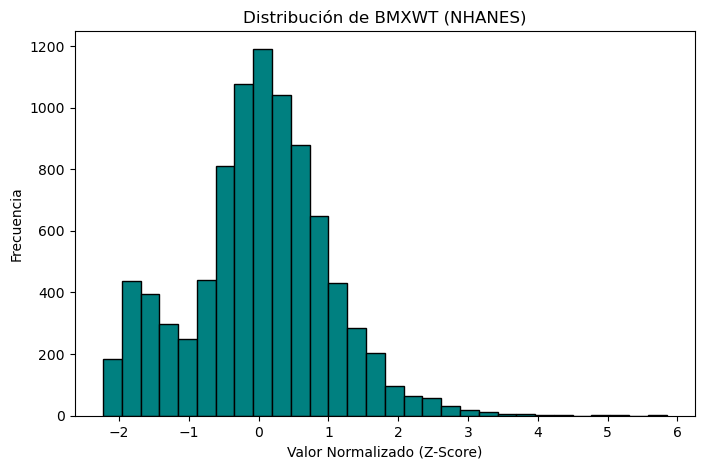

In [36]:
# Ver balanceo/distribución de la variable objetivo (SalePrice)
columna_real = 'BMXWT' 

plt.figure(figsize=(8, 5))
plt.hist(df_final_nhanes[columna_real], bins=30, color='teal', edgecolor='black')
plt.title(f'Distribución de {columna_real} (NHANES)')
plt.xlabel('Valor Normalizado (Z-Score)')
plt.ylabel('Frecuencia')
plt.show()

In [37]:
# Preparamos los insumos para el entrenamiento
# 2. Definir X (Características/Pistas) y y (Etiqueta/Respuesta)
# Quitamos el peso de X para que la IA no haga trampa
X = df_final_nhanes.drop(columna_real, axis=1).values
y = df_final_nhanes[columna_real].values

# 3. División 80% entrenamiento (para estudiar) y 20% prueba (el examen)
# El random_state=42 asegura que el ingeniero vea los mismos resultados que tú
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

print(f"Entrenamiento (X_train): {X_train.shape}")
print(f"Prueba (X_test): {X_test.shape}")

Entrenamiento (X_train): (7088, 46)
Prueba (X_test): (1772, 46)


In [38]:
print(f"¿Quedan nulos en el dataset?: {df_final_nhanes.isnull().sum().sum()}")
print(f"Registros totales procesados: {df_final_nhanes.shape[0]}")


¿Quedan nulos en el dataset?: 0
Registros totales procesados: 8860
